<a href="https://colab.research.google.com/github/RajShekhar0341/DataScience/blob/main/LDA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
#step 1: import libraries
import numpy as np
from sklearn import datasets
iris= datasets.load_iris()
X=iris.data
y=iris.target

In [10]:
print(X)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [11]:
#step 2 compute mean vectors
mean_vectors = []
for cls in np.unique(y):
  mean_vectors.append(np.mean(X[y == cls], axis=0))
print(mean_vectors)

[array([5.006, 3.428, 1.462, 0.246]), array([5.936, 2.77 , 4.26 , 1.326]), array([6.588, 2.974, 5.552, 2.026])]


In [12]:
#step 3: compute within class scatter matrix
S_W = np.zeros((X.shape[1], X.shape[1]))
for cls, mv in zip(np.unique(y), mean_vectors):
  class_sc_mat = np.zeros((X.shape[1], X.shape[1]))
  for row in X[y == cls]:
      row, mv = row.reshape(-1,1), mv.reshape(-1,1)
      class_sc_mat += (row - mv).dot((row - mv).T)
  S_W += class_sc_mat
  print(S_W)


[[6.0882 4.8616 0.8014 0.5062]
 [4.8616 7.0408 0.5732 0.4556]
 [0.8014 0.5732 1.4778 0.2974]
 [0.5062 0.4556 0.2974 0.5442]]
[[19.1434  9.0356  9.7634  3.2394]
 [ 9.0356 11.8658  4.6232  2.4746]
 [ 9.7634  4.6232 12.2978  3.8794]
 [ 3.2394  2.4746  3.8794  2.4604]]
[[38.9562 13.63   24.6246  5.645 ]
 [13.63   16.962   8.1208  4.8084]
 [24.6246  8.1208 27.2226  6.2718]
 [ 5.645   4.8084  6.2718  6.1566]]


In [13]:
#step 4: compute overall mean
overall_mean = np.mean(X, axis=0).reshape(-1,1)
print(overall_mean)

[[5.84333333]
 [3.05733333]
 [3.758     ]
 [1.19933333]]


In [14]:
#step 5: compute between class scatter matrix(sb)
S_B = np.zeros((X.shape[1], X.shape[1]))
for i, mean_vec in enumerate(mean_vectors):
    n = X[y == i].shape[0]
    mean_vec = mean_vec.reshape(-1,1)
    S_B += n * (mean_vec - overall_mean).dot((mean_vec - overall_mean).T)
print(S_B)

[[ 63.21213333 -19.95266667 165.2484      71.27933333]
 [-19.95266667  11.34493333 -57.2396     -22.93266667]
 [165.2484     -57.2396     437.1028     186.774     ]
 [ 71.27933333 -22.93266667 186.774       80.41333333]]


In [15]:
#step 6: compute Eigenvalues & Eigenvectors
eig_vals, eig_vecs = np.linalg.eig(np.linalg.inv(S_W).dot(S_B))
print(eig_vals)
print(eig_vecs)

[ 3.21919292e+01+0.00000000e+00j  2.85391043e-01+0.00000000e+00j
 -2.89074531e-15+2.36599826e-15j -2.89074531e-15-2.36599826e-15j]
[[-0.20874182+0.j         -0.00653196+0.j         -0.14156417+0.52573455j
  -0.14156417-0.52573455j]
 [-0.38620369+0.j         -0.58661055+0.j         -0.212536  -0.23040846j
  -0.212536  +0.23040846j]
 [ 0.55401172+0.j          0.25256154+0.j         -0.27030318-0.22892848j
  -0.27030318+0.22892848j]
 [ 0.7073504 +0.j         -0.76945309+0.j          0.69269842+0.j
   0.69269842-0.j        ]]


In [17]:
#step 7: Select top Linear Discrimints
sorted_indices = np.argsort(abs(eig_vals))[::-1]
W = eig_vecs[:, sorted_indices[:2]]
print(W)

[[-0.20874182+0.j -0.00653196+0.j]
 [-0.38620369+0.j -0.58661055+0.j]
 [ 0.55401172+0.j  0.25256154+0.j]
 [ 0.7073504 +0.j -0.76945309+0.j]]


In [18]:
#step 8: Transform Data
X_lda = X.dot(W)
print(X_lda)

[[-1.49920971+0.j -1.88675441+0.j]
 [-1.2643595 +0.j -1.59214275+0.j]
 [-1.35525305+0.j -1.73341462+0.j]
 [-1.18495616+0.j -1.62358806+0.j]
 [-1.5169559 +0.j -1.94476227+0.j]
 [-1.40864014+0.j -2.20148038+0.j]
 [-1.28548339+0.j -1.90177269+0.j]
 [-1.38431399+0.j -1.80218401+0.j]
 [-1.12136823+0.j -1.53021571+0.j]
 [-1.31831374+0.j -1.54860234+0.j]
 [-1.58367182+0.j -1.98077996+0.j]
 [-1.28716445+0.j -1.77562146+0.j]
 [-1.31422036+0.j -1.51454424+0.j]
 [-1.37605297+0.j -1.58704672+0.j]
 [-1.94923317+0.j -2.23514437+0.j]
 [-1.77516687+0.j -2.54725756+0.j]
 [-1.63024483+0.j -2.302505  +0.j]
 [-1.42847467+0.j -1.96369972+0.j]
 [-1.50337736+0.j -2.06783361+0.j]
 [-1.48893461+0.j -2.11442674+0.j]
 [-1.35700838+0.j -1.75428449+0.j]
 [-1.3795792 +0.j -2.13271099+0.j]
 [-1.65506386+0.j -2.0431741 +0.j]
 [-1.04356034+0.j -1.92449977+0.j]
 [-1.12096094+0.j -1.699853  +0.j]
 [-1.17443134+0.j -1.54228363+0.j]
 [-1.18744274+0.j -1.93081847+0.j]
 [-1.46468272+0.j -1.86215146+0.j]
 [-1.48146353+0.j -1

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


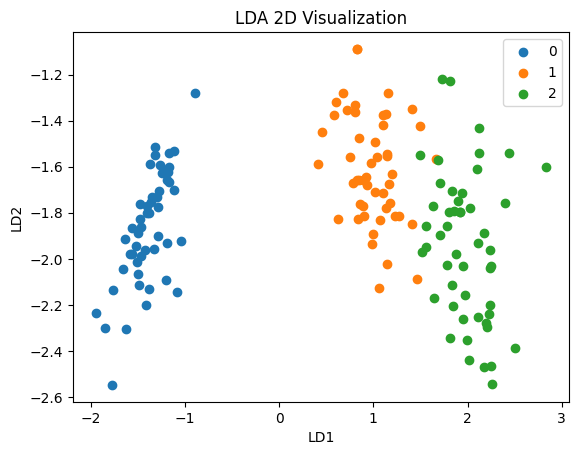

In [19]:
#visualization
import matplotlib.pyplot as plt
#2D Visualization
for i in np.unique(y):
  plt.scatter(X_lda[y == i, 0], X_lda[y == i, 1], label=i)
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA 2D Visualization")
plt.legend()
plt.show()